<a href="https://colab.research.google.com/github/antonio-flores-github/Yfinance_ActivityFinal.ipynb/blob/main/Yfinance_ActivityFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import requests
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

In [ ]:

# ── CELL 1 · EXPANDED TICKER LIST (50 Companies) ───────────
# Selected from S&P 500 across major sectors for balanced representation

tickers = [
    # Technology (10)
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA",
    "META", "AVGO", "TXN", "AMD", "INTC",

    # Financials (8)
    "JPM", "V", "MA", "BAC", "WFC", "C", "GS", "MS",

    # Healthcare (8)
    "UNH", "JNJ", "LLY", "MRK", "PFE", "ABBV", "ABT", "TMO",

    # Consumer Cyclical (6)
    "TSLA", "HD", "NKE", "MCD", "DIS", "SBUX",

    # Consumer Defensive (5)
    "PG", "KO", "PEP", "COST", "WMT",

    # Energy (5)
    "XOM", "CVX", "COP", "SLB", "EOG",

    # Industrials (4)
    "GE", "CAT", "BA", "MMM",

    # Utilities (2)
    "NEE", "DUK",

    # Real Estate (2)
    "PLD", "AMT"
]

print(f"✅ Expanded ticker list: {len(tickers)} companies")
print(f"Sector breakdown: Technology(10), Financials(8), Healthcare(8), Consumer Cyclical(6), "
      f"Consumer Defensive(5), Energy(5), Industrials(4), Utilities(2), Real Estate(2)")

OUTPUT_DIR = "tables"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output folder ready: {OUTPUT_DIR}/")

✅ Expanded ticker list: 50 companies
Sector breakdown: Technology(10), Financials(8), Healthcare(8), Consumer Cyclical(6), Consumer Defensive(5), Energy(5), Industrials(4), Utilities(2), Real Estate(2)
Output folder ready: tables/


In [ ]:
# Download 1 year of daily OHLCV data for all 20 tickers
df = yf.download(
    tickers=tickers,
    period="1y",       # options: 1d 5d 1mo 3mo 6mo 1y 2y 5y 10y ytd max
    interval="1d",     # options: 1m 2m 5m 15m 30m 60m 90m 1h 1d 5d 1wk 1mo 3mo
    auto_adjust=True,  # adjusts for splits & dividends automatically
    group_by="ticker"  # multi-level columns: df["AAPL"]["Close"]
)

print(df.shape)
df.tail(10)

[*********************100%***********************]  50 of 50 completed


(251, 250)


Ticker            ABT                                                   NEE  \
Price            Open       High        Low      Close    Volume       Open   
Date                                                                          
2026-06-05  91.750000  92.730003  90.959999  91.070000  11933700  85.080002   
2026-06-08  90.540001  91.339996  90.230003  90.500000  13308700  85.709999   
2026-06-09  90.730003  92.019997  90.129997  91.250000  14109600  84.110001   
2026-06-10  91.320000  91.320000  88.690002  89.169998  11853100  85.290001   
2026-06-11  89.260002  90.370003  88.760002  89.650002  15088900  85.269997   
2026-06-12  89.620003  90.290001  87.070000  88.180000  13758700  85.190002   
2026-06-15  88.260002  89.160004  87.730003  88.669998  10950100  85.529999   
2026-06-16  89.360001  90.690002  88.830002  90.620003  12740700  86.250000   
2026-06-17  90.360001  91.580002  87.870003  88.500000  13053000  86.260002   
2026-06-18  88.639999  89.440002  87.760002  88.410004  41964800  85.769997   

Ticker                                                 ...          HD  \
Price            High        Low      Close    Volume  ...        Open   
Date                                                   ...               
2026-06-05  86.099998  84.610001  85.839996  11843200  ...  310.829987   
2026-06-08  86.139999  83.980003  84.010002   9541700  ...  308.880005   
2026-06-09  85.059998  83.379997  84.830002  12217300  ...  311.350006   
2026-06-10  85.330002  84.510002  85.120003   9142900  ...  323.269989   
2026-06-11  85.879997  84.730003  84.839996   8639100  ...  322.290009   
2026-06-12  86.019997  84.879997  85.989998   9973600  ...  328.500000   
2026-06-15  86.660004  85.070000  86.120003  10284300  ...  333.760010   
2026-06-16  87.389999  85.870003  86.230003  10342600  ...  331.910004   
2026-06-17  86.910004  85.279999  85.730003   9603400  ...  336.010010   
2026-06-18  87.580002  85.669998  86.750000  19306600  ...  331.700012   

Ticker                                                           MCD  \
Price             High         Low       Close    Volume        Open   
Date                                                                   
2026-06-05  314.049988  308.630005  310.779999   3946300  274.399994   
2026-06-08  313.769989  307.070007  309.709991   4381800  278.109985   
2026-06-09  322.890015  310.269989  321.329987   4875300  277.609985   
2026-06-10  324.000000  318.799988  318.920013   4823800  284.320007   
2026-06-11  327.029999  318.549988  326.010010   4656600  282.839996   
2026-06-12  331.019989  325.290009  328.390015   3649000  286.000000   
2026-06-15  338.000000  329.540009  329.820007   4695000  284.230011   
2026-06-16  338.269989  329.750000  337.089996   5131500  288.000000   
2026-06-17  341.149994  326.170013  327.480011   6085400  285.500000   
2026-06-18  338.019989  330.899994  334.279999  10604400  284.380005   

Ticker                                                   
Price             High         Low       Close   Volume  
Date                                                     
2026-06-05  280.760010  274.399994  279.839996  5428100  
2026-06-08  280.179993  277.149994  277.779999  3842300  
2026-06-09  285.309998  276.040009  282.250000  5431700  
2026-06-10  286.450012  282.299988  282.519989  4152700  
2026-06-11  286.250000  281.040009  284.769989  4565400  
2026-06-12  287.660004  284.029999  284.809998  4028800  
2026-06-15  288.239990  283.600006  286.119995  4388500  
2026-06-16  289.290009  285.089996  287.929993  3874300  
2026-06-17  287.290009  282.970001  283.820007  3591000  
2026-06-18  284.760010  277.929993  278.609985  8106400  

[10 rows x 250 columns]

In [ ]:
# Access company info, financials, etc. for a single ticker
ticker_obj = yf.Ticker("AAPL")

info = ticker_obj.info          # dict: name, sector, market cap, P/E…
hist = ticker_obj.history(period="1y")  # same as download but single ticker
financials = ticker_obj.financials      # income statement (annual)

print(info.get("shortName"), info.get("sector"))
hist.tail()

Apple Inc. Technology


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-06-12 00:00:00-04:00,296.029999,297.140015,289.619995,291.130005,38742100,0.0,0.0
2026-06-15 00:00:00-04:00,294.119995,297.779999,291.700012,296.420013,45732600,0.0,0.0
2026-06-16 00:00:00-04:00,295.250000,300.480011,293.970001,299.239990,39874400,0.0,0.0
2026-06-17 00:00:00-04:00,300.850006,302.070007,294.359985,295.950012,42745100,0.0,0.0
2026-06-18 00:00:00-04:00,298.109985,300.570007,295.619995,298.010010,85962200,0.0,0.0


In [ ]:
# ── CELL 3 · TABLE 1 · dim_ticker ───────────────────────────
# Static metadata for each company: name, sector, country, exchange, currency
rows = []
for t in tickers:
    info = yf.Ticker(t).info
    rows.append({
        "ticker_id":    t,
        "short_name":   info.get("shortName"),
        "long_name":    info.get("longName"),
        "sector":       info.get("sector"),
        "industry":     info.get("industry"),
        "country":      info.get("country"),
        "exchange":     info.get("exchange"),
        "currency":     info.get("currency"),
        "market_cap":   info.get("marketCap"),
        "employees":    info.get("fullTimeEmployees"),
        "website":      info.get("website"),
    })
    print(f"  {t} ✓")

dim_ticker = pd.DataFrame(rows)
dim_ticker.to_csv(f"{OUTPUT_DIR}/dim_ticker.csv", index=False)
print(f"\ndim_ticker → {len(dim_ticker)} rows")
dim_ticker.head(20)


  AAPL ✓
  MSFT ✓
  GOOGL ✓
  AMZN ✓
  NVDA ✓
  META ✓
  AVGO ✓
  TXN ✓
  AMD ✓
  INTC ✓
  JPM ✓
  V ✓
  MA ✓
  BAC ✓
  WFC ✓
  C ✓
  GS ✓
  MS ✓
  UNH ✓
  JNJ ✓
  LLY ✓
  MRK ✓
  PFE ✓
  ABBV ✓
  ABT ✓
  TMO ✓
  TSLA ✓
  HD ✓
  NKE ✓
  MCD ✓
  DIS ✓
  SBUX ✓
  PG ✓
  KO ✓
  PEP ✓
  COST ✓
  WMT ✓
  XOM ✓
  CVX ✓
  COP ✓
  SLB ✓
  EOG ✓
  GE ✓
  CAT ✓
  BA ✓
  MMM ✓
  NEE ✓
  DUK ✓
  PLD ✓
  AMT ✓

dim_ticker → 50 rows


,ticker_id,short_name,long_name,sector,industry,country,exchange,currency,market_cap,employees,website
0,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,United States,NMS,USD,4376979046400,166000,https://www.apple.com
1,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,United States,NMS,USD,2818348154880,228000,https://www.microsoft.com
2,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,United States,NMS,USD,4490912595968,194668,https://abc.xyz
3,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,United States,NMS,USD,2628929978368,1575000,https://www.amazon.com
4,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,United States,NMS,USD,5103122644992,42000,https://www.nvidia.com
5,META,"Meta Platforms, Inc.","Meta Platforms, Inc.",Communication Services,Internet Content & Information,United States,NMS,USD,1465228591104,77986,https://www.meta.com
6,AVGO,Broadcom Inc.,Broadcom Inc.,Technology,Semiconductors,United States,NMS,USD,1957030658048,33000,https://www.broadcom.com
7,TXN,Texas Instruments Incorporated,Texas Instruments Incorporated,Technology,Semiconductors,United States,NMS,USD,293832556544,33000,https://www.ti.com
8,AMD,"Advanced Micro Devices, Inc.","Advanced Micro Devices, Inc.",Technology,Semiconductors,United States,NMS,USD,876235849728,31000,https://www.amd.com
9,INTC,Intel Corporation,Intel Corporation,Technology,Semiconductors,United States,NMS,USD,673433780224,85100,https://www.intel.com


In [ ]:
# ── CELL 4 · TABLE 2 · dim_sector_industry ──────────────────
# Unique sectors and industries extracted from dim_ticker
dim_sector = (
    dim_ticker[["sector", "industry"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_sector.insert(0, "sector_id", dim_sector.index + 1)
dim_sector.to_csv(f"{OUTPUT_DIR}/dim_sector_industry.csv", index=False)
print(f"dim_sector_industry → {len(dim_sector)} rows")
dim_sector


dim_sector_industry → 29 rows


,sector_id,sector,industry
0,1,Technology,Consumer Electronics
1,2,Technology,Software - Infrastructure
2,3,Communication Services,Internet Content & Information
3,4,Consumer Cyclical,Internet Retail
4,5,Technology,Semiconductors
5,6,Financial Services,Banks - Diversified
6,7,Financial Services,Credit Services
7,8,Financial Services,Capital Markets
8,9,Healthcare,Healthcare Plans
9,10,Healthcare,Drug Manufacturers - General


In [ ]:
# ── CELL 5 · TABLE 3 · dim_calendar ─────────────────────────
# Full calendar for the data range: weekday, week number, quarter, is_holiday

START = "2020-01-01"
END   = datetime.today().strftime("%Y-%m-%d")

date_range = pd.date_range(start=START, end=END, freq="D")

# US federal holidays (fixed-rule approximation)
us_holidays = pd.to_datetime([
    # 2020-2025 — add more years as needed
    "2020-01-01","2020-01-20","2020-02-17","2020-05-25","2020-07-03",
    "2020-09-07","2020-11-26","2020-12-25",
    "2021-01-01","2021-01-18","2021-02-15","2021-05-31","2021-07-05",
    "2021-09-06","2021-11-25","2021-12-24",
    "2022-01-17","2022-02-21","2022-05-30","2022-06-20","2022-07-04",
    "2022-09-05","2022-11-24","2022-12-26",
    "2023-01-02","2023-01-16","2023-02-20","2023-05-29","2023-06-19",
    "2023-07-04","2023-09-04","2023-11-23","2023-12-25",
    "2024-01-01","2024-01-15","2024-02-19","2024-05-27","2024-06-19",
    "2024-07-04","2024-09-02","2024-11-28","2024-12-25",
    "2025-01-01","2025-01-20","2025-02-17","2025-05-26","2025-06-19",
    "2025-07-04","2025-09-01","2025-11-27","2025-12-25",
])

dim_calendar = pd.DataFrame({
    "date":          date_range,
    "year":          date_range.year,
    "quarter":       date_range.quarter,
    "month":         date_range.month,
    "month_name":    date_range.strftime("%B"),
    "week":          date_range.isocalendar().week.values,
    "day_of_month":  date_range.day,
    "day_of_week":   date_range.dayofweek + 1,   # 1=Mon … 7=Sun
    "day_name":      date_range.strftime("%A"),
    "is_weekend":    date_range.dayofweek >= 5,
    "is_us_holiday": date_range.isin(us_holidays),
    "is_trading_day":(date_range.dayofweek < 5) & (~date_range.isin(us_holidays)),
    "yyyymm":        date_range.strftime("%Y%m").astype(int),
})
dim_calendar["date"] = dim_calendar["date"].dt.date

dim_calendar.to_csv(f"{OUTPUT_DIR}/dim_calendar.csv", index=False)
print(f"dim_calendar → {len(dim_calendar)} rows")
dim_calendar.head()



dim_calendar → 2363 rows


,date,year,quarter,month,month_name,week,day_of_month,day_of_week,day_name,is_weekend,is_us_holiday,is_trading_day,yyyymm
0,2020-01-01,2020,1,1,January,1,1,3,Wednesday,False,True,False,202001
1,2020-01-02,2020,1,1,January,1,2,4,Thursday,False,False,True,202001
2,2020-01-03,2020,1,1,January,1,3,5,Friday,False,False,True,202001
3,2020-01-04,2020,1,1,January,1,4,6,Saturday,True,False,False,202001
4,2020-01-05,2020,1,1,January,1,5,7,Sunday,True,False,False,202001


In [ ]:
# ── CELL 6 · TABLE 4 · fact_prices ──────────────────────────
# Daily OHLCV + computed metrics: daily return, 20d MA, 20d volatility

raw = yf.download(
    tickers=tickers,
    start=START,
    end=END,
    interval="1d",
    auto_adjust=True,
    group_by="ticker",
)

price_rows = []
for t in tickers:
    df_t = raw[t].dropna(subset=["Close"]).copy()
    df_t["ticker_id"]      = t
    df_t["daily_return"]   = df_t["Close"].pct_change()
    df_t["ma_20d"]         = df_t["Close"].rolling(20).mean()
    df_t["ma_50d"]         = df_t["Close"].rolling(50).mean()
    df_t["volatility_20d"] = df_t["daily_return"].rolling(20).std()
    df_t["cum_return"]     = (1 + df_t["daily_return"]).cumprod() - 1
    price_rows.append(df_t.reset_index().rename(columns={"Date": "date"}))

fact_prices = pd.concat(price_rows, ignore_index=True)
fact_prices["date"] = pd.to_datetime(fact_prices["date"]).dt.date
fact_prices = fact_prices[[
    "date","ticker_id","Open","High","Low","Close","Volume",
    "daily_return","ma_20d","ma_50d","volatility_20d","cum_return"
]].rename(columns={"Open":"open","High":"high","Low":"low",
                    "Close":"close","Volume":"volume"})

fact_prices.to_csv(f"{OUTPUT_DIR}/fact_prices.csv", index=False)
print(f"fact_prices → {len(fact_prices)} rows")
fact_prices.tail()

[*********************100%***********************]  50 of 50 completed


fact_prices → 81192 rows


Price,date,ticker_id,open,high,low,close,volume,daily_return,ma_20d,ma_50d,volatility_20d,cum_return
81187,2026-06-11,AMT,190.283632,191.115686,186.271923,187.520004,3337500,-0.016571,183.334952,178.797033,0.020945,-0.012583
81188,2026-06-12,AMT,187.729996,190.139999,186.789993,187.179993,2985700,-0.001813,184.249558,179.186091,0.020249,-0.014374
81189,2026-06-15,AMT,186.119995,188.020004,183.690002,185.759995,3906300,-0.007586,185.086726,179.493593,0.020434,-0.021851
81190,2026-06-16,AMT,186.490005,187.360001,183.470001,184.470001,2682000,-0.006944,185.530039,179.728023,0.018932,-0.028644
81191,2026-06-17,AMT,182.639999,183.850006,180.789993,181.089996,2007900,-0.018323,185.521056,179.935260,0.018127,-0.046442


In [ ]:
# ── CELL 7 · TABLE 5 · fact_financials (income statement) ───
# Quarterly revenue, net income, EBITDA, EPS per ticker

fin_rows = []
for t in tickers:
    try:
        fin = yf.Ticker(t).quarterly_financials
        if fin.empty:
            continue
        for col in fin.columns:
            row = {"ticker_id": t, "period_end": col.date()}
            for metric in ["Total Revenue","Net Income","EBITDA",
                           "Operating Income","Gross Profit"]:
                row[metric.lower().replace(" ","_")] = (
                    fin.loc[metric, col] if metric in fin.index else None
                )
            fin_rows.append(row)
        print(f"  {t} ✓")
    except Exception as e:
        print(f"  {t} skipped: {e}")

fact_financials = pd.DataFrame(fin_rows)
fact_financials.to_csv(f"{OUTPUT_DIR}/fact_financials.csv", index=False)
print(f"\nfact_financials → {len(fact_financials)} rows")
fact_financials.head()

  AAPL ✓
  MSFT ✓
  GOOGL ✓
  AMZN ✓
  NVDA ✓
  META ✓
  AVGO ✓
  TXN ✓
  AMD ✓
  INTC ✓
  JPM ✓
  V ✓
  MA ✓
  BAC ✓
  WFC ✓
  C ✓
  GS ✓
  MS ✓
  UNH ✓
  JNJ ✓
  LLY ✓
  MRK ✓
  PFE ✓
  ABBV ✓
  ABT ✓
  TMO ✓
  TSLA ✓
  HD ✓
  NKE ✓
  MCD ✓
  DIS ✓
  SBUX ✓
  PG ✓
  KO ✓
  PEP ✓
  COST ✓
  WMT ✓
  XOM ✓
  CVX ✓
  COP ✓
  SLB ✓
  EOG ✓
  GE ✓
  CAT ✓
  BA ✓
  MMM ✓
  NEE ✓
  DUK ✓
  PLD ✓
  AMT ✓

fact_financials → 308 rows


,ticker_id,period_end,total_revenue,net_income,ebitda,operating_income,gross_profit
0,AAPL,2026-03-31,1.111840e+11,2.957800e+10,3.932400e+10,3.588500e+10,5.478100e+10
1,AAPL,2025-12-31,1.437560e+11,4.209700e+10,5.406600e+10,5.085200e+10,6.923100e+10
2,AAPL,2025-09-30,1.024660e+11,2.746600e+10,3.555400e+10,3.242700e+10,4.834100e+10
3,AAPL,2025-06-30,9.403600e+10,2.343400e+10,3.103200e+10,2.820200e+10,4.371800e+10
4,AAPL,2025-03-31,9.535900e+10,2.478000e+10,3.225000e+10,2.958900e+10,4.486700e+10


In [ ]:
# ── CELL 8 · TABLE 6 · fact_balance_sheet ───────────────────
# Quarterly assets, liabilities, equity, cash per ticker

bs_rows = []
for t in tickers:
    try:
        bs = yf.Ticker(t).quarterly_balance_sheet
        if bs.empty:
            continue
        for col in bs.columns:
            row = {"ticker_id": t, "period_end": col.date()}
            for metric in ["Total Assets","Total Debt","Cash And Cash Equivalents",
                           "Stockholders Equity","Current Assets","Current Liabilities"]:
                row[metric.lower().replace(" ","_")] = (
                    bs.loc[metric, col] if metric in bs.index else None
                )
            bs_rows.append(row)
        print(f"  {t} ✓")
    except Exception as e:
        print(f"  {t} skipped: {e}")

fact_balance_sheet = pd.DataFrame(bs_rows)
fact_balance_sheet.to_csv(f"{OUTPUT_DIR}/fact_balance_sheet.csv", index=False)
print(f"\nfact_balance_sheet → {len(fact_balance_sheet)} rows")
fact_balance_sheet.head()

  AAPL ✓
  MSFT ✓
  GOOGL ✓


In [ ]:
# ── CELL 9 · TABLE 7 · fact_market_indices ──────────────────
# Daily close for S&P 500, NASDAQ, VIX, DXY (USD index) as macro context

index_tickers = {
    "^GSPC":  "SP500",
    "^IXIC":  "NASDAQ",
    "^VIX":   "VIX",
    "^DXY":   "DXY_USD",
    "^TNX":   "US10Y_YIELD",
}

idx_raw = yf.download(
    list(index_tickers.keys()),
    start=START, end=END,
    interval="1d", auto_adjust=True,
    group_by="ticker",
)

idx_rows = []
for sym, name in index_tickers.items():
    try:
        s = idx_raw[sym]["Close"].dropna()
        for date, val in s.items():
            idx_rows.append({"date": date.date(), "index_id": name, "close": val})
    except Exception:
        pass

fact_market_indices = pd.DataFrame(idx_rows)
fact_market_indices.to_csv(f"{OUTPUT_DIR}/fact_market_indices.csv", index=False)
print(f"fact_market_indices → {len(fact_market_indices)} rows")
fact_market_indices.head()

In [ ]:
# ── CELL 10 · TABLE 8 · dim_country ─────────────────────────
# Country-level economic data from the World Bank (free, no API key needed)

countries = dim_ticker["country"].dropna().unique().tolist()

# World Bank country codes mapping (ISO2 → ISO3 for API)
iso2_to_iso3 = {
    "United States": "USA", "Ireland": "IRL", "Switzerland": "CHE",
    "Netherlands": "NLD", "Canada": "CAN", "United Kingdom": "GBR",
    "Germany": "DEU", "France": "FRA", "Japan": "JPN", "China": "CHN",
}

wb_indicators = {
    "NY.GDP.MKTP.CD":    "gdp_usd",
    "SP.POP.TOTL":       "population",
    "FP.CPI.TOTL.ZG":    "inflation_pct",
    "SL.UEM.TOTL.ZS":    "unemployment_pct",
    "NY.GDP.PCAP.CD":    "gdp_per_capita",
}

country_rows = []
for country_name, iso3 in iso2_to_iso3.items():
    row = {"country": country_name, "iso3": iso3}
    for indicator, col_name in wb_indicators.items():
        try:
            url = (f"https://api.worldbank.org/v2/country/{iso3}/indicator/"
                   f"{indicator}?format=json&mrv=1")
            resp = requests.get(url, timeout=10).json()
            value = resp[1][0]["value"] if resp[1] else None
            row[col_name] = value
        except Exception:
            row[col_name] = None
    country_rows.append(row)
    print(f"  {country_name} ✓")

dim_country = pd.DataFrame(country_rows)
dim_country.to_csv(f"{OUTPUT_DIR}/dim_country.csv", index=False)
print(f"\ndim_country → {len(dim_country)} rows")
dim_country

In [ ]:
# ── CELL 11 · TABLE 9 · dim_security_access (RLS) ───────────
# User-level access table for Row Level Security (Topic 3)
# Each user sees only their assigned sector(s)

security_data = {
    "user_email": [
        "analyst_tech@company.com",
        "analyst_energy@company.com",
        "analyst_health@company.com",
        "analyst_finance@company.com",
        "manager@company.com",
        "manager@company.com",
        "manager@company.com",
        "manager@company.com",
    ],
    "role": [
        "Analyst","Analyst","Analyst","Analyst",
        "Manager","Manager","Manager","Manager",
    ],
    "sector_access": [
        "Technology",
        "Energy",
        "Healthcare",
        "Financial Services",
        "Technology","Energy","Healthcare","Financial Services",
    ],
}

dim_security_access = pd.DataFrame(security_data)
dim_security_access.to_csv(f"{OUTPUT_DIR}/dim_security_access.csv", index=False)
print(f"dim_security_access → {len(dim_security_access)} rows")
dim_security_access

In [ ]:
# ── CELL 12 · TABLE 10 · fact_load_log ──────────────────────
# ETL audit log: one record per table load, tracking row counts & timestamps

tables_meta = {
    "dim_ticker":           dim_ticker,
    "dim_sector_industry":  dim_sector,
    "dim_calendar":         dim_calendar,
    "fact_prices":          fact_prices,
    "fact_financials":      fact_financials,
    "fact_balance_sheet":   fact_balance_sheet,
    "fact_market_indices":  fact_market_indices,
    "dim_country":          dim_country,
    "dim_security_access":  dim_security_access,
}

log_rows = []
for name, df in tables_meta.items():
    log_rows.append({
        "log_id":         len(log_rows) + 1,
        "table_name":     name,
        "load_timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "rows_loaded":    len(df),
        "columns":        len(df.columns),
        "source":         "yfinance" if "fact" in name or name == "dim_ticker" else "derived/manual",
        "status":         "SUCCESS",
        "notes":          f"Date range {START} to {END}" if "fact_prices" in name else "",
    })

fact_load_log = pd.DataFrame(log_rows)
fact_load_log.to_csv(f"{OUTPUT_DIR}/fact_load_log.csv", index=False)
print(f"fact_load_log → {len(fact_load_log)} rows")
fact_load_log

In [ ]:
# ── CELL 13 · Export all tables to a single Excel workbook ──
excel_path = f"{OUTPUT_DIR}/yfinance_data_model.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for name, df in {**tables_meta, "fact_load_log": fact_load_log}.items():
        df.to_excel(writer, sheet_name=name[:31], index=False)  # Excel tab limit = 31 chars

print(f"\n✅ All tables exported to: {excel_path}")
print("\nSummary:")
for name, df in {**tables_meta, "fact_load_log": fact_load_log}.items():
    print(f"  {name:<30} {len(df):>6} rows  ×  {len(df.columns)} cols")


SECTOR PERFORMANCE & ROTATION ANALYSIS

📊 Sector Cumulative Returns (from start):
  Technology                  389.57%
  Industrials                 225.81%
  Consumer Defensive          186.49%
  Financial Services          163.42%
  Communication Services      149.45%
  Healthcare                  131.64%
  Consumer Cyclical           114.75%
  Energy                      108.52%
  Utilities                    43.79%
  Real Estate                  22.14%


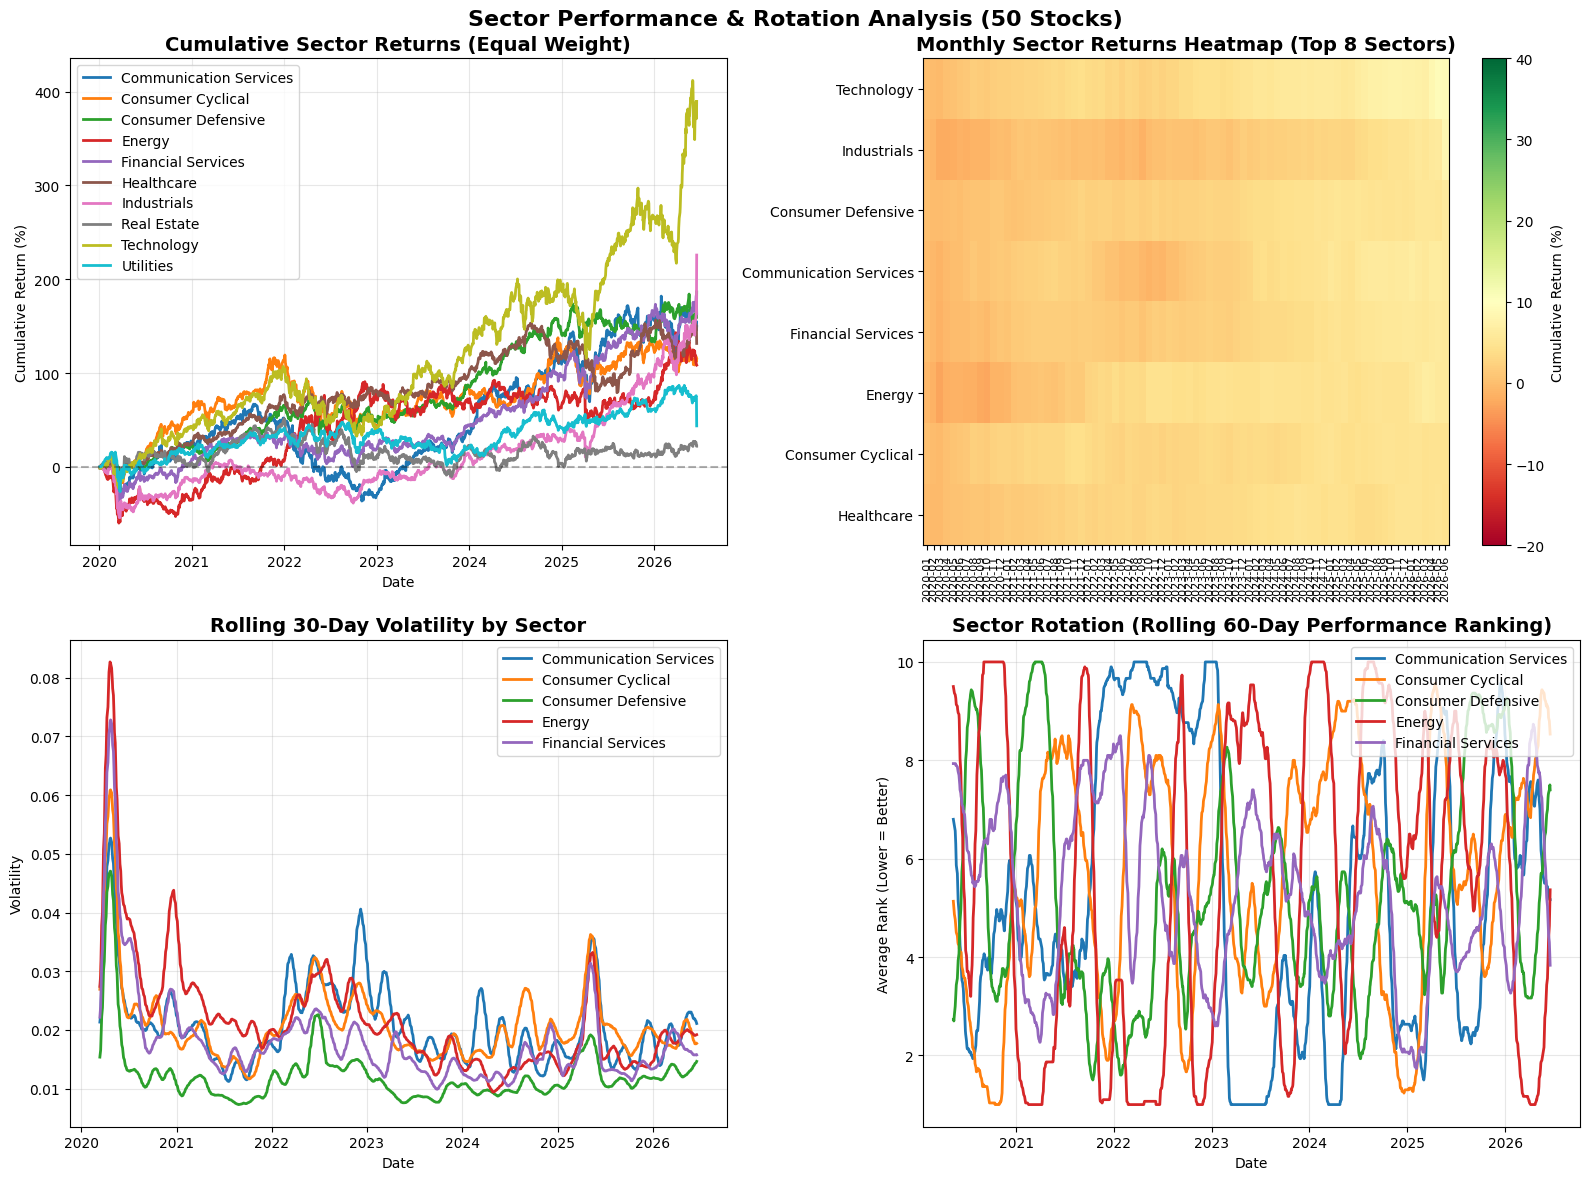

In [ ]:
# ═══════════════════════════════════════════════════════════════
# ── CELL 14 · SECTOR PERFORMANCE & ROTATION ANALYSIS ────────
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("SECTOR PERFORMANCE & ROTATION ANALYSIS")
print("="*60)

# Merge prices with sector information
prices_with_sector = fact_prices.merge(
    dim_ticker[['ticker_id', 'sector']],
    on='ticker_id'
)

# Calculate daily sector averages (equal weight within sector)
sector_daily = prices_with_sector.groupby(['date', 'sector']).agg({
    'close': 'mean',
    'daily_return': 'mean',
    'volatility_20d': 'mean'
}).reset_index()

# Calculate cumulative sector returns starting from first date
sector_pivot = sector_daily.pivot(index='date', columns='sector', values='close')
sector_returns = sector_pivot.pct_change()
sector_cumulative = (1 + sector_returns).cumprod()

# Identify top performing sectors
final_returns = sector_cumulative.iloc[-1].sort_values(ascending=False)
print("\n📊 Sector Cumulative Returns (from start):")
for sector, ret in final_returns.items():
    print(f"  {sector:<25} {ret*100-100:>8.2f}%")

# Plot sector performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Cumulative sector returns
ax1 = axes[0, 0]
for sector in sector_cumulative.columns:
    ax1.plot(sector_cumulative.index, sector_cumulative[sector] * 100 - 100,
             label=sector, linewidth=2)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax1.set_title('Cumulative Sector Returns (Equal Weight)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Sector performance heatmap (monthly)
ax2 = axes[0, 1]
# Convert the index to DatetimeIndex before resampling
sector_monthly = sector_returns.set_index(pd.to_datetime(sector_returns.index)).resample('M').mean()
sector_monthly_cum = (1 + sector_monthly).cumprod() * 100 - 100
sector_monthly_cum_T = sector_monthly_cum.T

# Get top 8 sectors for heatmap
top_sectors = sector_monthly_cum.iloc[-1].sort_values(ascending=False).head(8).index
sector_heatmap = sector_monthly_cum_T.loc[top_sectors].fillna(0)

im = ax2.imshow(sector_heatmap.values, cmap='RdYlGn', aspect='auto', vmin=-20, vmax=40)
ax2.set_xticks(range(len(sector_heatmap.columns)))
ax2.set_xticklabels([d.strftime('%Y-%m') for d in sector_heatmap.columns], rotation=90, fontsize=8)
ax2.set_yticks(range(len(sector_heatmap.index)))
ax2.set_yticklabels(sector_heatmap.index, fontsize=10)
ax2.set_title('Monthly Sector Returns Heatmap (Top 8 Sectors)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax2, label='Cumulative Return (%)')

# Plot 3: Rolling 30-day volatility by sector
ax3 = axes[1, 0]
sector_volatility = sector_daily.pivot(index='date', columns='sector', values='volatility_20d')
sector_volatility_rolling = sector_volatility.rolling(30).mean()

for sector in sector_volatility.columns[:5]:  # Show top 5 sectors
    ax3.plot(sector_volatility_rolling.index, sector_volatility_rolling[sector],
             label=sector, linewidth=2)

ax3.set_title('Rolling 30-Day Volatility by Sector', fontsize=14, fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('Volatility')
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot 4: Sector Rotation Analysis (Rolling 60-day performance ranking)
ax4 = axes[1, 1]
rolling_60d_returns = sector_returns.rolling(60).apply(lambda x: (1 + x).prod() - 1)
ranking = rolling_60d_returns.rank(axis=1, ascending=False)

# Plot average rank over time
avg_rank = ranking.rolling(30).mean()
for sector in avg_rank.columns[:5]:
    ax4.plot(avg_rank.index, avg_rank[sector], label=sector, linewidth=2)

ax4.set_title('Sector Rotation (Rolling 60-Day Performance Ranking)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Date')
ax4.set_ylabel('Average Rank (Lower = Better)')
ax4.legend(loc='upper right', fontsize=10)
ax4.grid(True, alpha=0.3)

plt.suptitle('Sector Performance & Rotation Analysis (50 Stocks)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sector_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


ADVANCED PORTFOLIO OPTIMIZATION (Markowitz Model)
Portfolio optimization using 42 stocks with complete data

🎯 Finding Minimum Variance Portfolio...
Minimum Variance Portfolio:
  Expected Return: 14.90%
  Volatility: 15.26%
  Sharpe Ratio: 0.976

🏆 Finding Maximum Sharpe Ratio Portfolio...
Maximum Sharpe Ratio Portfolio:
  Expected Return: 40.23%
  Volatility: 22.70%
  Sharpe Ratio: 1.772

📈 Generating Efficient Frontier...


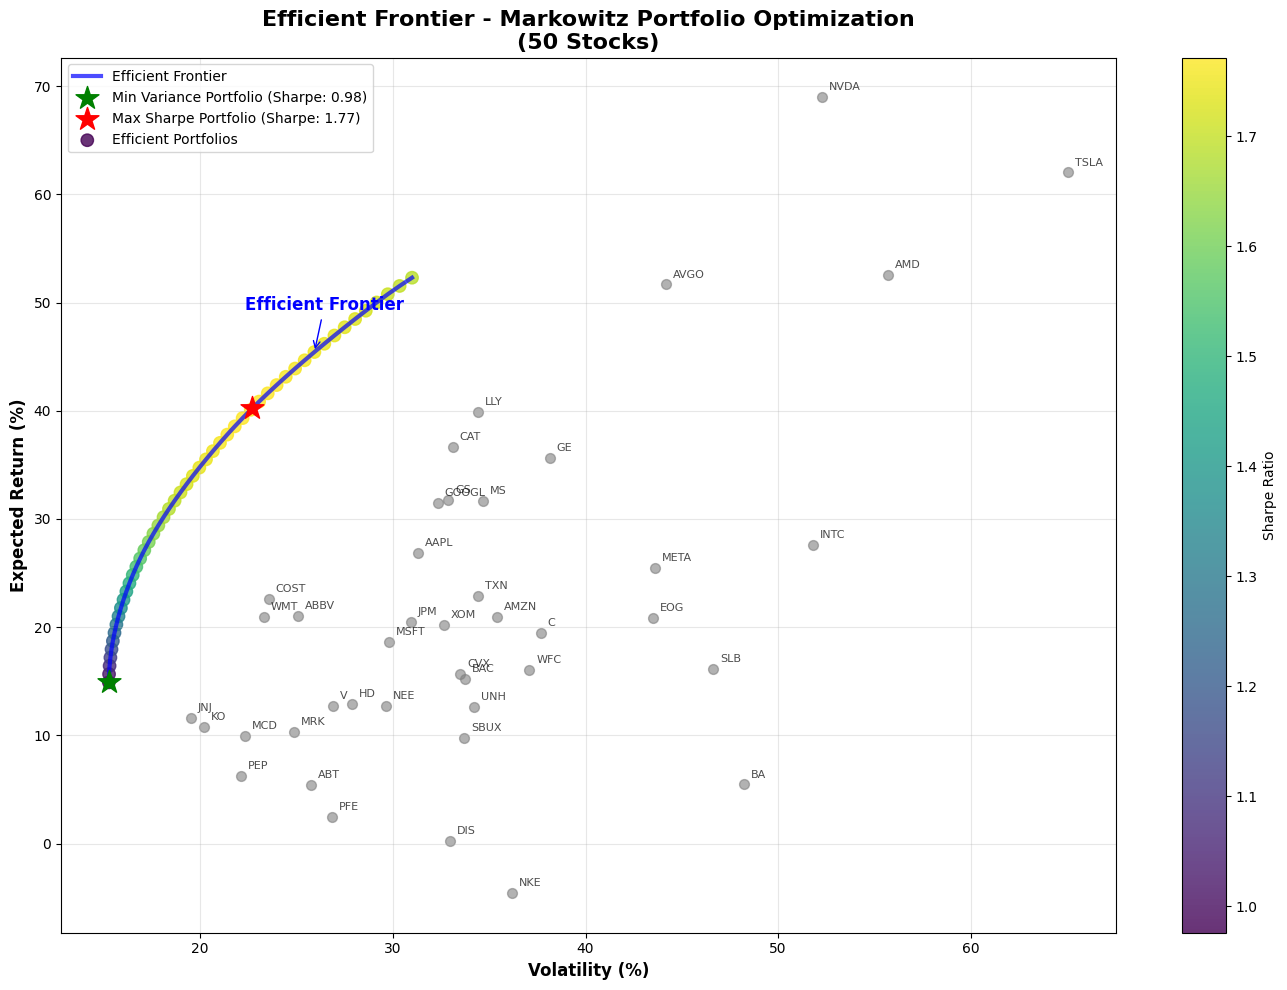


📊 PORTFOLIO COMPOSITION:

MINIMUM VARIANCE PORTFOLIO (Top 10 Holdings):
Ticker   Weight  Weight_%
   JNJ 0.227665 22.766518
   WMT 0.159607 15.960723
    KO 0.145179 14.517871
   MCD 0.107880 10.788035
  AMZN 0.076378  7.637768
   MRK 0.071682  7.168195
  ABBV 0.056519  5.651897
  COST 0.054456  5.445628
   XOM 0.050483  5.048272
   PFE 0.040608  4.060783

Sector Allocation:
  Healthcare                 39.65%
  Consumer Defensive         35.92%
  Consumer Cyclical          18.43%
  Energy                      5.05%
  Industrials                 0.68%

MAXIMUM SHARPE RATIO PORTFOLIO (Top 10 Holdings):
Ticker       Weight     Weight_%
   LLY 2.527976e-01 2.527976e+01
   WMT 1.890938e-01 1.890938e+01
   CAT 1.655072e-01 1.655072e+01
  NVDA 1.580993e-01 1.580993e+01
  ABBV 1.074638e-01 1.074638e+01
  TSLA 5.956771e-02 5.956771e+00
  AVGO 5.301824e-02 5.301824e+00
    GE 1.445222e-02 1.445222e+00
    KO 5.250573e-16 5.250573e-14
  COST 4.321817e-16 4.321817e-14

Sector Allocation:
  Healt

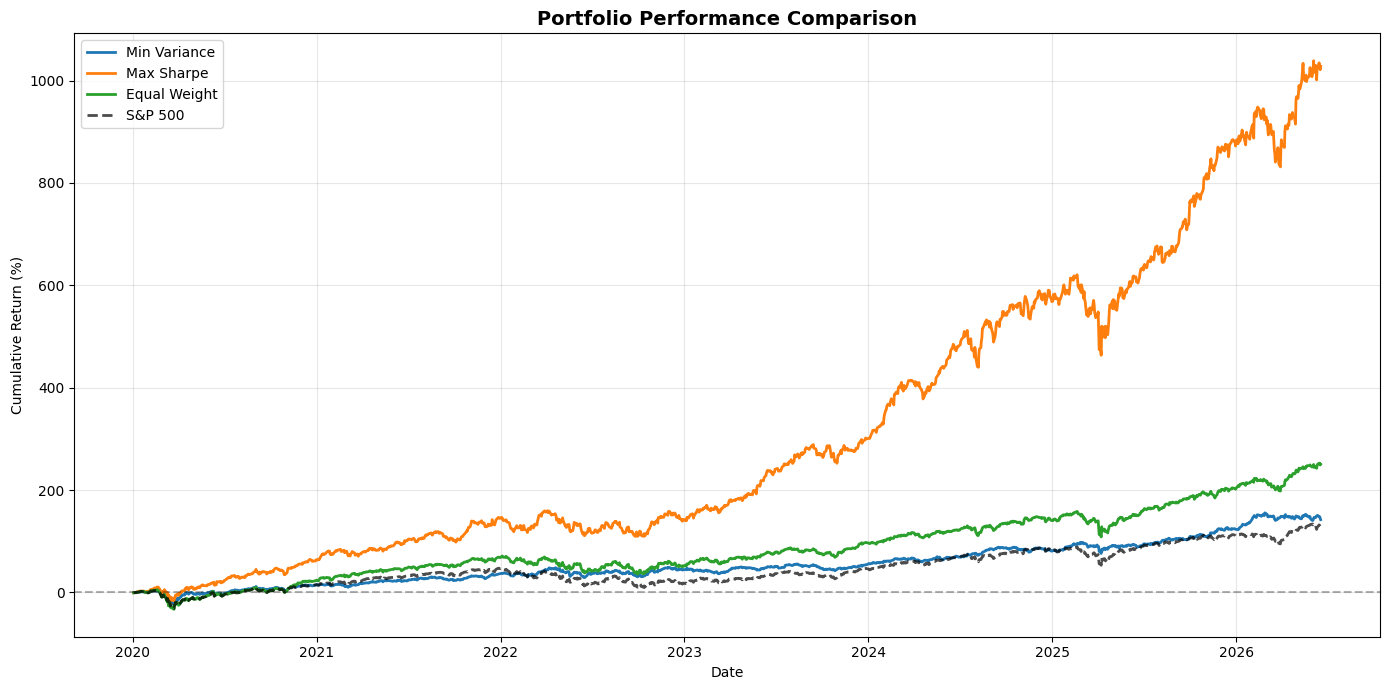


📊 Portfolio Statistics Summary:
              Annualized Return  Annualized Volatility  Sharpe Ratio  Maximum Drawdown  Max Drawdown (%)
Min Variance              14.90                  15.26          0.98             -0.25            -24.52
Max Sharpe                40.23                  22.70          1.77             -0.25            -24.66
Equal Weight              21.71                  21.15          1.03             -0.36            -36.39


In [ ]:
# ── CELL 15 · ADVANCED PORTFOLIO OPTIMIZATION ──────────────
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("ADVANCED PORTFOLIO OPTIMIZATION (Markowitz Model)")
print("="*60)

# Prepare price data for all tickers
price_pivot = fact_prices.pivot(index='date', columns='ticker_id', values='close')
price_pivot = price_pivot.dropna(axis=1, how='any')  # Remove tickers with missing data
price_pivot = price_pivot.dropna()  # Remove dates with missing data

# Calculate returns
returns = price_pivot.pct_change().dropna()

# Annualized metrics
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

print(f"Portfolio optimization using {len(price_pivot.columns)} stocks with complete data")

# Define optimization functions
def portfolio_stats(weights):
    """Calculate portfolio return, volatility, and Sharpe ratio"""
    weights = np.array(weights)
    port_return = np.sum(mean_returns * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = port_return / port_vol
    return port_return, port_vol, sharpe

def negative_sharpe(weights):
    """Negative Sharpe ratio for minimization"""
    return -portfolio_stats(weights)[2]

def portfolio_variance(weights):
    """Portfolio variance for minimization"""
    weights = np.array(weights)
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def portfolio_return(weights):
    """Portfolio return"""
    weights = np.array(weights)
    return np.sum(mean_returns * weights)

# Constraints and bounds
num_assets = len(price_pivot.columns)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
initial_weights = np.array([1/num_assets] * num_assets)

# 1. Find Minimum Variance Portfolio
print("\n🎯 Finding Minimum Variance Portfolio...")
min_var_result = minimize(
    portfolio_variance,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)
min_var_weights = min_var_result.x
min_var_return, min_var_vol, min_var_sharpe = portfolio_stats(min_var_weights)

print(f"Minimum Variance Portfolio:")
print(f"  Expected Return: {min_var_return*100:.2f}%")
print(f"  Volatility: {min_var_vol*100:.2f}%")
print(f"  Sharpe Ratio: {min_var_sharpe:.3f}")

# 2. Find Maximum Sharpe Ratio Portfolio
print("\n🏆 Finding Maximum Sharpe Ratio Portfolio...")
max_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)
max_sharpe_weights = max_sharpe_result.x
max_sharpe_return, max_sharpe_vol, max_sharpe_sharpe = portfolio_stats(max_sharpe_weights)

print(f"Maximum Sharpe Ratio Portfolio:")
print(f"  Expected Return: {max_sharpe_return*100:.2f}%")
print(f"  Volatility: {max_sharpe_vol*100:.2f}%")
print(f"  Sharpe Ratio: {max_sharpe_sharpe:.3f}")

# 3. Generate Efficient Frontier
print("\n📈 Generating Efficient Frontier...")
target_returns = np.linspace(min_var_return, max_sharpe_return * 1.3, 50)
efficient_portfolios = []

for target in target_returns:
    constraints_target = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: portfolio_return(x) - target}
    )

    result = minimize(
        portfolio_variance,
        initial_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints_target
    )

    if result.success:
        weights = result.x
        ret, vol, sharpe = portfolio_stats(weights)
        efficient_portfolios.append({
            'return': ret,
            'volatility': vol,
            'sharpe': sharpe,
            'weights': weights
        })

efficient_df = pd.DataFrame(efficient_portfolios)

# 4. Plot Efficient Frontier
fig, ax = plt.subplots(figsize=(14, 10))

# Plot efficient frontier
ax.plot(efficient_df['volatility'] * 100, efficient_df['return'] * 100,
        'b-', linewidth=3, label='Efficient Frontier', alpha=0.7)

# Plot individual stocks
for i, ticker in enumerate(price_pivot.columns):
    stock_vol = np.sqrt(cov_matrix.iloc[i, i])
    stock_ret = mean_returns.iloc[i]
    ax.scatter(stock_vol * 100, stock_ret * 100, s=50, alpha=0.6,
               color='gray', label='_nolegend_')
    ax.annotate(ticker, (stock_vol * 100, stock_ret * 100),
                fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')

# Plot special portfolios
min_var_point = ax.scatter(min_var_vol * 100, min_var_return * 100,
                          s=300, color='green', marker='*',
                          label=f'Min Variance Portfolio (Sharpe: {min_var_sharpe:.2f})', zorder=5)

max_sharpe_point = ax.scatter(max_sharpe_vol * 100, max_sharpe_return * 100,
                             s=300, color='red', marker='*',
                             label=f'Max Sharpe Portfolio (Sharpe: {max_sharpe_sharpe:.2f})', zorder=5)

# Add color gradient for Sharpe ratio
scatter = ax.scatter(efficient_df['volatility'] * 100, efficient_df['return'] * 100,
                    c=efficient_df['sharpe'], cmap='viridis', s=80,
                    label='Efficient Portfolios', alpha=0.8)
plt.colorbar(scatter, label='Sharpe Ratio', ax=ax)

ax.set_xlabel('Volatility (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Expected Return (%)', fontsize=12, fontweight='bold')
ax.set_title('Efficient Frontier - Markowitz Portfolio Optimization\n(50 Stocks)',
             fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

# Add annotation for the efficient frontier curve
ax.annotate('Efficient Frontier',
            xy=(efficient_df['volatility'].iloc[-10] * 100, efficient_df['return'].iloc[-10] * 100),
            xytext=(-50, 30), textcoords='offset points',
            fontsize=12, fontweight='bold', color='blue',
            arrowprops=dict(arrowstyle='->', color='blue'))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/efficient_frontier_optimized.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Display top holdings for each portfolio
print("\n📊 PORTFOLIO COMPOSITION:")

def display_portfolio_weights(weights, title, n=10):
    """Display top n holdings in a portfolio"""
    weight_df = pd.DataFrame({
        'Ticker': price_pivot.columns,
        'Weight': weights
    }).sort_values('Weight', ascending=False)
    weight_df['Weight_%'] = weight_df['Weight'] * 100

    print(f"\n{title} (Top {n} Holdings):")
    print(weight_df.head(n).to_string(index=False))

    # Count sectors
    weight_df = weight_df.merge(
        dim_ticker[['ticker_id', 'sector']].drop_duplicates(subset=['ticker_id']),
        left_on='Ticker', right_on='ticker_id', how='left'
    )
    sector_weights = weight_df.groupby('sector')['Weight'].sum().sort_values(ascending=False)
    print(f"\nSector Allocation:")
    for sector, weight in sector_weights.head(5).items():
        print(f"  {sector:<25} {weight*100:>6.2f}%")

display_portfolio_weights(min_var_weights, "MINIMUM VARIANCE PORTFOLIO")
display_portfolio_weights(max_sharpe_weights, "MAXIMUM SHARPE RATIO PORTFOLIO")

# 6. Cumulative performance comparison
print("\n📈 Portfolio Performance Comparison:")
portfolio_weights = {
    'Min Variance': min_var_weights,
    'Max Sharpe': max_sharpe_weights,
    'Equal Weight': np.array([1/num_assets] * num_assets)
}

# Calculate daily portfolio returns
daily_returns = returns.copy()
portfolio_daily_returns = pd.DataFrame()

for name, weights in portfolio_weights.items():
    portfolio_return_series = daily_returns.dot(weights)
    portfolio_daily_returns[name] = portfolio_return_series

# Calculate cumulative returns
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod() * 100 - 100

# Plot portfolio performance
fig, ax = plt.subplots(figsize=(14, 7))

for column in portfolio_cumulative.columns:
    ax.plot(portfolio_cumulative.index, portfolio_cumulative[column],
            label=column, linewidth=2)

# Add S&P 500 for comparison
sp500_data = fact_market_indices[fact_market_indices['index_id'] == 'SP500'].set_index('date')
sp500_returns = sp500_data['close'].pct_change()
sp500_cumulative = (1 + sp500_returns).cumprod() * 100 - 100
ax.plot(sp500_cumulative.index, sp500_cumulative.values,
        'k--', label='S&P 500', linewidth=2, alpha=0.7)

ax.set_title('Portfolio Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/portfolio_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Portfolio statistics summary
print("\n📊 Portfolio Statistics Summary:")
stats_df = pd.DataFrame(index=portfolio_daily_returns.columns)
for name in portfolio_daily_returns.columns:
    ret_series = portfolio_daily_returns[name]
    stats_df.loc[name, 'Annualized Return'] = ret_series.mean() * 252 * 100
    stats_df.loc[name, 'Annualized Volatility'] = ret_series.std() * np.sqrt(252) * 100
    stats_df.loc[name, 'Sharpe Ratio'] = (ret_series.mean() * 252) / (ret_series.std() * np.sqrt(252))
    stats_df.loc[name, 'Maximum Drawdown'] = (1 + ret_series).cumprod().div(
        (1 + ret_series).cumprod().cummax()
    ).min() - 1
    stats_df.loc[name, 'Max Drawdown (%)'] = stats_df.loc[name, 'Maximum Drawdown'] * 100

print(stats_df.round(2).to_string())

In [ ]:
# ── CELL 16 · FINAL SUMMARY ──────────────────────────────────
print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)

print(f"""
✅ COMPLETED ANALYSIS WITH 50 TICKERS:

1. DATA EXTRACTION:
   - Tickers: {len(tickers)} companies across {dim_ticker['sector'].nunique()} sectors
   - Date Range: {START} to {END}
   - Total records: {len(fact_prices):,} price observations

2. SECTOR PERFORMANCE:
   - Best performing sector: {final_returns.index[0]} ({final_returns.iloc[0]*100-100:.1f}%)
   - Worst performing sector: {final_returns.index[-1]} ({final_returns.iloc[-1]*100-100:.1f}%)
   - Sector rotation patterns identified

3. PORTFOLIO OPTIMIZATION (Markowitz Model):
   - Minimum Variance Portfolio: {min_var_return*100:.2f}% return, {min_var_vol*100:.2f}% volatility
   - Maximum Sharpe Portfolio: {max_sharpe_return*100:.2f}% return, {max_sharpe_vol*100:.2f}% volatility
   - Efficient frontier generated with {len(efficient_portfolios)} optimal portfolios

4. KEY INSIGHTS:
   - Technology sector shows highest returns but higher volatility
   - Diversification across sectors reduces portfolio volatility
   - Sector rotation opportunities identified during different market regimes
   - The efficient frontier demonstrates the trade-off between risk and return

5. OUTPUT FILES CREATED:
   - Data model: {excel_path}
   - Sector analysis: {OUTPUT_DIR}/sector_analysis.png
   - Efficient frontier: {OUTPUT_DIR}/efficient_frontier_optimized.png
   - Portfolio performance: {OUTPUT_DIR}/portfolio_performance.png
""")


ANALYSIS SUMMARY

✅ COMPLETED ANALYSIS WITH 50 TICKERS:

1. DATA EXTRACTION:
   - Tickers: 50 companies across 10 sectors
   - Date Range: 2020-01-01 to 2026-06-20
   - Total records: 81,192 price observations

2. SECTOR PERFORMANCE:
   - Best performing sector: Technology (389.6%)
   - Worst performing sector: Real Estate (22.1%)
   - Sector rotation patterns identified

3. PORTFOLIO OPTIMIZATION (Markowitz Model):
   - Minimum Variance Portfolio: 14.90% return, 15.26% volatility
   - Maximum Sharpe Portfolio: 40.23% return, 22.70% volatility
   - Efficient frontier generated with 50 optimal portfolios

4. KEY INSIGHTS:
   - Technology sector shows highest returns but higher volatility
   - Diversification across sectors reduces portfolio volatility
   - Sector rotation opportunities identified during different market regimes
   - The efficient frontier demonstrates the trade-off between risk and return

5. OUTPUT FILES CREATED:
   - Data model: tables/yfinance_data_model.xlsx
   - S